# Math for Machine Learning — Linear Algebra Week 3
## Vectors, Matrices, Dot Products, Matrix Multiplication, and Linear Transformations

This notebook converts the Week 3 PDF topics into runnable Jupyter Notebook code.

Topics covered:
- Vectors and vector properties
- L1 and L2 norms
- Vector addition, subtraction, scalar multiplication
- Distances between vectors
- Dot product and geometric meaning
- Matrix-vector multiplication
- Matrices as linear transformations
- Matrix multiplication
- Identity matrix and inverse matrix
- Simple perceptron examples for NLP/spam and AND logic

In [27]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

def show_vector(v, start=(0, 0), label=None):
    """Plot a 2D vector from a starting point."""
    v = np.array(v, dtype=float)
    start = np.array(start, dtype=float)
    plt.arrow(start[0], start[1], v[0], v[1],
              head_width=0.2, length_includes_head=True)
    if label:
        end = start + v
        plt.text(end[0] + 0.1, end[1] + 0.1, label)

def setup_axes(limit=6):
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.grid(True)
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.gca().set_aspect('equal', adjustable='box')

## 1. Vectors

A vector can represent movement or direction.  
For example, the vector `(4, 3)` means move 4 units in the horizontal direction and 3 units in the vertical direction.

Vector u = [4 3]


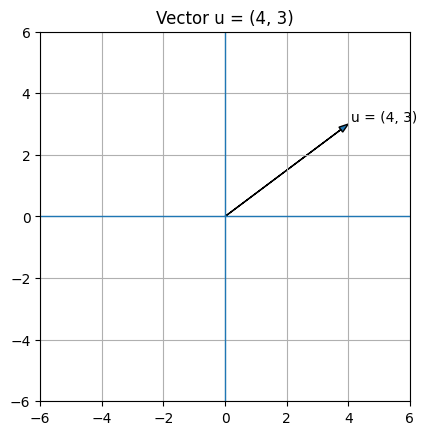

In [2]:
u = np.array([4, 3])
print("Vector u =", u)

plt.figure()
setup_axes(6)
show_vector(u, label="u = (4, 3)")
plt.title("Vector u = (4, 3)")
plt.show()

## 2. Norms of a Vector

For vector `u = (a, b)`:

- L1 norm: `|a| + |b|`
- L2 norm: `sqrt(a^2 + b^2)`

For `u = (4, 3)`:
- L1 norm = 4 + 3 = 7
- L2 norm = sqrt(4² + 3²) = 5

In [3]:
u = np.array([4, 3])

l1_norm = np.linalg.norm(u, ord=1)
l2_norm = np.linalg.norm(u, ord=2)

print("u =", u)
print("L1 norm =", l1_norm)
print("L2 norm =", l2_norm)

u = [4 3]
L1 norm = 7.0
L2 norm = 5.0


## 3. Direction of a Vector

The direction angle θ of vector `(4, 3)` can be found using:

`theta = arctan(y/x)`

In [4]:
u = np.array([4, 3])

theta_radians = np.arctan2(u[1], u[0])
theta_degrees = np.degrees(theta_radians)

print("Angle in radians:", theta_radians)
print("Angle in degrees:", theta_degrees)

Angle in radians: 0.6435011087932844
Angle in degrees: 36.86989764584402


## 4. Vector Addition

If:

`u = (4, 1)` and `v = (1, 3)`

then:

`u + v = (5, 4)`

u = [4 1]
v = [1 3]
u + v = [5 4]


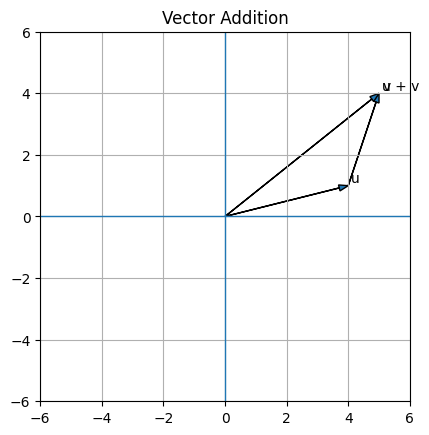

In [5]:
u = np.array([4, 1])
v = np.array([1, 3])
w = u + v

print("u =", u)
print("v =", v)
print("u + v =", w)

plt.figure()
setup_axes(6)
show_vector(u, label="u")
show_vector(v, start=u, label="v")
show_vector(w, label="u + v")
plt.title("Vector Addition")
plt.show()

## 5. Vector Difference

If:

`u = (4, 1)` and `v = (1, 3)`

then:

`u - v = (3, -2)`

u = [4 1]
v = [1 3]
u - v = [ 3 -2]


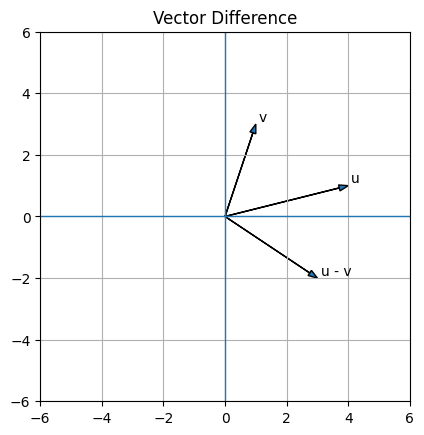

In [6]:
u = np.array([4, 1])
v = np.array([1, 3])
difference = u - v

print("u =", u)
print("v =", v)
print("u - v =", difference)

plt.figure()
setup_axes(6)
show_vector(u, label="u")
show_vector(v, label="v")
show_vector(difference, label="u - v")
plt.title("Vector Difference")
plt.show()

## 6. Distance Between Vectors

For:

`u = (6, 2)` and `v = (1, 5)`

`u - v = (5, -3)`

- L1 distance = `|5| + |-3| = 8`
- L2 distance = `sqrt(5² + (-3)²) ≈ 5.83`

u = [6 2]
v = [1 5]
u - v = [ 5 -3]
L1 distance = 8.0
L2 distance = 5.830951894845301


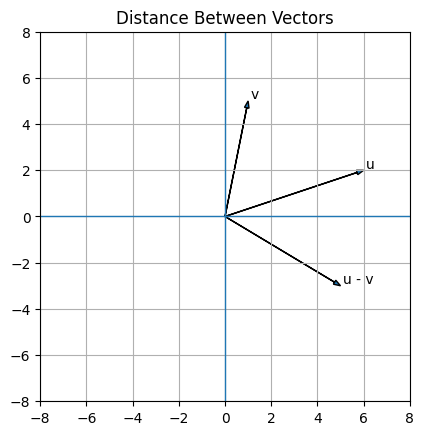

In [7]:
u = np.array([6, 2])
v = np.array([1, 5])

diff = u - v
l1_distance = np.linalg.norm(diff, ord=1)
l2_distance = np.linalg.norm(diff, ord=2)

print("u =", u)
print("v =", v)
print("u - v =", diff)
print("L1 distance =", l1_distance)
print("L2 distance =", l2_distance)

plt.figure()
setup_axes(8)
show_vector(u, label="u")
show_vector(v, label="v")
show_vector(diff, label="u - v")
plt.title("Distance Between Vectors")
plt.show()

## 7. Scalar Multiplication

Multiplying a vector by a scalar stretches, shrinks, or reverses the vector.

Example:

`u = (1, 2)`

`3u = (3, 6)`

`-2u = (-2, -4)`

u = [1 2]
3u = [3 6]
-2u = [-2 -4]


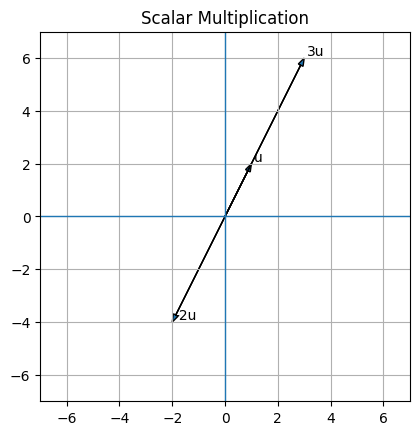

In [8]:
u = np.array([1, 2])

print("u =", u)
print("3u =", 3 * u)
print("-2u =", -2 * u)

plt.figure()
setup_axes(7)
show_vector(u, label="u")
show_vector(3*u, label="3u")
show_vector(-2*u, label="-2u")
plt.title("Scalar Multiplication")
plt.show()

## 8. Dot Product

The dot product multiplies matching entries and adds them.

Example:

Quantities: `(2, 4, 1)`  
Prices: `(3, 5, 2)`

Total price:

`2*3 + 4*5 + 1*2 = 28`

In [9]:
quantities = np.array([2, 4, 1])
prices = np.array([3, 5, 2])

total = np.dot(quantities, prices)

print("Quantities =", quantities)
print("Prices =", prices)
print("Dot product / total price =", total)

Quantities = [2 4 1]
Prices = [3 5 2]
Dot product / total price = 28


## 9. Norm Using Dot Product

For `u = (4, 3)`:

`u · u = 4² + 3² = 25`

So:

`||u|| = sqrt(u · u) = 5`

In [10]:
u = np.array([4, 3])

dot_self = np.dot(u, u)
norm = np.sqrt(dot_self)

print("u · u =", dot_self)
print("sqrt(u · u) =", norm)
print("np.linalg.norm(u) =", np.linalg.norm(u))

u · u = 25
sqrt(u · u) = 5.0
np.linalg.norm(u) = 5.0


## 10. Orthogonal Vectors

Two vectors are orthogonal/perpendicular if their dot product is 0.

Example:

`u = (6, 2)`  
`v = (-1, 3)`

`6*(-1) + 2*3 = -6 + 6 = 0`

u = [6 2]
v = [-1  3]
u · v = 0


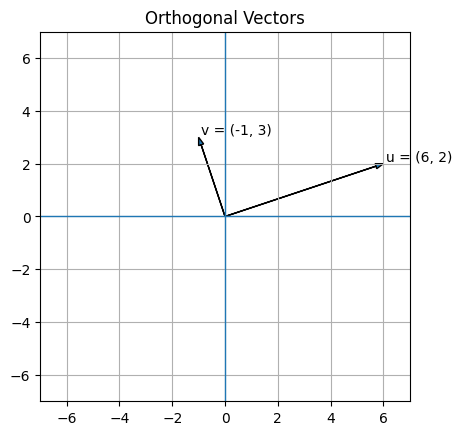

In [11]:
u = np.array([6, 2])
v = np.array([-1, 3])

dot_uv = np.dot(u, v)

print("u =", u)
print("v =", v)
print("u · v =", dot_uv)

plt.figure()
setup_axes(7)
show_vector(u, label="u = (6, 2)")
show_vector(v, label="v = (-1, 3)")
plt.title("Orthogonal Vectors")
plt.show()

## 11. Geometric Meaning of Dot Product

The dot product is:

`u · v = ||u|| ||v|| cos(theta)`

- Positive dot product: angle is less than 90°
- Zero dot product: vectors are perpendicular
- Negative dot product: angle is greater than 90°

In [12]:
examples = [
    (np.array([6, 2]), np.array([-1, 3])),
    (np.array([6, 2]), np.array([2, 4])),
    (np.array([6, 2]), np.array([-4, 1])),
]

for u, v in examples:
    dot = np.dot(u, v)
    print(f"u={u}, v={v}, dot={dot}")

u=[6 2], v=[-1  3], dot=0
u=[6 2], v=[2 4], dot=20
u=[6 2], v=[-4  1], dot=-22


## 12. Equations as Dot Products

The equation:

`2a + 4b + c = 28`

can be written as:

`[2, 4, 1] · [a, b, c] = 28`

In [13]:
coefficients = np.array([2, 4, 1])
variables = np.array([3, 5, 2])  # Example values for a, b, c

result = np.dot(coefficients, variables)

print("Coefficients:", coefficients)
print("Variables:", variables)
print("Dot product:", result)

Coefficients: [2 4 1]
Variables: [3 5 2]
Dot product: 28


## 13. System of Equations as Matrix-Vector Product

System:

```
a + b + c = 10
a + 2b + c = 15
a + b + 2c = 12
```

Matrix form:

`Ax = b`

In [14]:
A = np.array([
    [1, 1, 1],
    [1, 2, 1],
    [1, 1, 2]
], dtype=float)

b = np.array([10, 15, 12], dtype=float)

solution = np.linalg.solve(A, b)

print("A =")
print(A)
print("\nb =", b)
print("\nSolution [a, b, c] =", solution)
print("\nCheck A @ solution =", A @ solution)

A =
[[1. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]]

b = [10. 15. 12.]

Solution [a, b, c] = [3. 5. 2.]

Check A @ solution = [10. 15. 12.]


## 14. Matrix as a Linear Transformation

A matrix transforms input vectors into output vectors.

Example matrix:

```
A = [[3, 1],
     [1, 2]]
```

This sends:
- `(1, 0)` to `(3, 1)`
- `(0, 1)` to `(1, 2)`
- `(1, 1)` to `(4, 3)`

In [28]:
A = np.array([
    [3, 1],
    [1, 2]
], dtype=float)

vectors = [
    np.array([0, 0]),
    np.array([1, 0]),
    np.array([0, 1]),
    np.array([1, 1]),
    np.array([-2, 3])
]

for x in vectors:
    print(f"A @ {x} = {A @ x}")

A @ [0 0] = [0. 0.]
A @ [1 0] = [3. 1.]
A @ [0 1] = [1. 2.]
A @ [1 1] = [4. 3.]
A @ [-2  3] = [-3.  4.]


### Visualizing a Linear Transformation

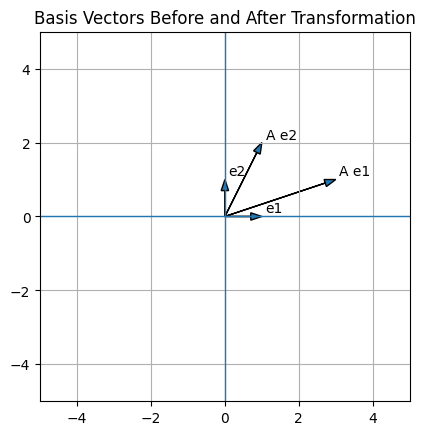

In [29]:
A = np.array([[3, 1], [1, 2]], dtype=float)

basis_vectors = [np.array([1, 0]), np.array([0, 1])]
transformed_vectors = [A @ e for e in basis_vectors]

plt.figure()
setup_axes(5)
show_vector(basis_vectors[0], label="e1")
show_vector(basis_vectors[1], label="e2")
show_vector(transformed_vectors[0], label="A e1")
show_vector(transformed_vectors[1], label="A e2")
plt.title("Basis Vectors Before and After Transformation")
plt.show()

## 15. Linear Transformation from Basis Images

If a transformation sends:

`(1, 0) -> (3, -1)`  
`(0, 1) -> (2, 3)`

then the matrix is formed by placing those transformed vectors as columns:

```
[[3, 2],
 [-1, 3]]
```

In [30]:
T = np.array([
    [3, 2],
    [-1, 3]
], dtype=float)

print("Transformation matrix T:")
print(T)

x = np.array([1, 1])
print("\nT @ (1, 1) =", T @ x)

Transformation matrix T:
[[ 3.  2.]
 [-1.  3.]]

T @ (1, 1) = [5. 2.]


## 16. Matrix Multiplication

Combining two linear transformations means multiplying matrices.

Example:

```
A = [[3, 1],
     [1, 2]]

B = [[2, -1],
     [0, 2]]
```

The combined transformation is `B @ A` if we apply `A` first and then `B`.

In [31]:
A = np.array([
    [3, 1],
    [1, 2]
], dtype=float)

B = np.array([
    [2, -1],
    [0, 2]
], dtype=float)

BA = B @ A
AB = A @ B

print("A =")
print(A)
print("\nB =")
print(B)
print("\nB @ A =")
print(BA)
print("\nA @ B =")
print(AB)

print("\nNotice: usually A @ B is not the same as B @ A.")

A =
[[3. 1.]
 [1. 2.]]

B =
[[ 2. -1.]
 [ 0.  2.]]

B @ A =
[[5. 0.]
 [2. 4.]]

A @ B =
[[ 6. -1.]
 [ 2.  3.]]

Notice: usually A @ B is not the same as B @ A.


## 17. Identity Matrix

The identity matrix leaves vectors unchanged.

`I @ x = x`

In [32]:
I = np.eye(5)
x = np.array([1, 2, 3, 4, 5])

print("Identity matrix I:")
print(I)
print("\nx =", x)
print("I @ x =", I @ x)

Identity matrix I:
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

x = [1 2 3 4 5]
I @ x = [1. 2. 3. 4. 5.]


## 18. Matrix Inverse

The inverse matrix reverses a transformation.

If `A` has an inverse, then:

`A_inv @ A = I`

Example:

```
A = [[3, 1],
     [1, 2]]
```

In [33]:
A = np.array([
    [3, 1],
    [1, 2]
], dtype=float)

A_inv = np.linalg.inv(A)

print("A =")
print(A)
print("\nA inverse =")
print(A_inv)
print("\nA_inv @ A =")
print(A_inv @ A)

A =
[[3. 1.]
 [1. 2.]]

A inverse =
[[ 0.4 -0.2]
 [-0.2  0.6]]

A_inv @ A =
[[1. 0.]
 [0. 1.]]


## 19. Quiz Example: Find the Inverse

Find the inverse of:

```
[[5, 2],
 [1, 2]]
```

The solution from the slides is:

```
[[ 1/4, -1/4],
 [-1/8,  5/8]]
```

In [34]:
A = np.array([
    [5, 2],
    [1, 2]
], dtype=float)

A_inv = np.linalg.inv(A)

print("A =")
print(A)
print("\nA inverse =")
print(A_inv)
print("\nCheck A @ A_inv =")
print(A @ A_inv)

A =
[[5. 2.]
 [1. 2.]]

A inverse =
[[ 0.25  -0.25 ]
 [-0.125  0.625]]

Check A @ A_inv =
[[1. 0.]
 [0. 1.]]


## 20. Non-Invertible Matrix

A singular matrix does not have an inverse.

Example:

```
[[1, 1],
 [2, 2]]
```

The second row is just twice the first row, so the determinant is 0.

In [35]:
A = np.array([
    [1, 1],
    [2, 2]
], dtype=float)

det_A = np.linalg.det(A)

print("A =")
print(A)
print("\nDeterminant =", det_A)

try:
    print(np.linalg.inv(A))
except np.linalg.LinAlgError as e:
    print("Inverse does not exist:", e)

A =
[[1. 1.]
 [2. 2.]]

Determinant = 0.0
Inverse does not exist: Singular matrix


## 21. Simple NLP Spam Classifier Using Dot Product

The PDF uses a toy spam classifier with two features:

- Number of times "Lottery" appears
- Number of times "Win" appears

Model:

`score = 1*Lottery + 1*Win`

Rule:

If `score > 1.5`, classify as spam.

In [36]:
# Columns: Lottery, Win
X = np.array([
    [1, 1],
    [2, 1],
    [0, 0],
    [0, 2],
    [0, 1],
    [1, 0],
    [2, 2],
    [2, 0],
    [1, 2]
])

true_labels = np.array(["Yes", "Yes", "No", "Yes", "No", "No", "Yes", "Yes", "Yes"])

weights = np.array([1, 1])
threshold = 1.5

scores = X @ weights
predictions = np.where(scores > threshold, "Yes", "No")

print("Features [Lottery, Win]:")
print(X)
print("\nScores:", scores)
print("Predictions:", predictions)
print("True labels:", true_labels)
print("Accuracy:", np.mean(predictions == true_labels))

Features [Lottery, Win]:
[[1 1]
 [2 1]
 [0 0]
 [0 2]
 [0 1]
 [1 0]
 [2 2]
 [2 0]
 [1 2]]

Scores: [2 3 0 2 1 1 4 2 3]
Predictions: ['Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes']
True labels: ['Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes']
Accuracy: 1.0


### Plotting the Spam Classifier Boundary

The decision boundary is:

`Lottery + Win = 1.5`

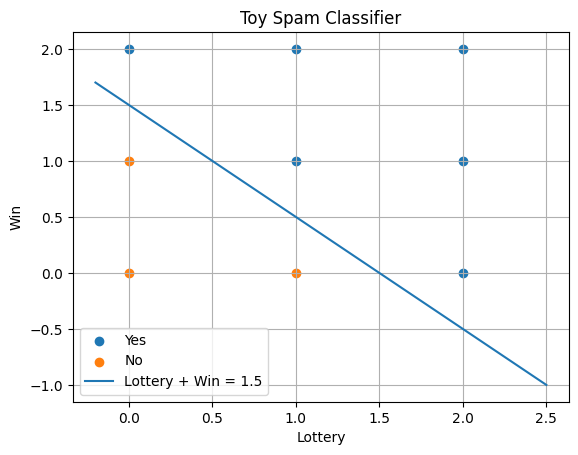

In [37]:
lottery = X[:, 0]
win = X[:, 1]

plt.figure()
for label in ["Yes", "No"]:
    mask = true_labels == label
    plt.scatter(lottery[mask], win[mask], label=label)

x_line = np.linspace(-0.2, 2.5, 100)
y_line = 1.5 - x_line

plt.plot(x_line, y_line, label="Lottery + Win = 1.5")
plt.xlabel("Lottery")
plt.ylabel("Win")
plt.title("Toy Spam Classifier")
plt.grid(True)
plt.legend()
plt.show()

## 22. Threshold and Bias

Instead of:

`Lottery + Win > 1.5`

we can write:

`Lottery + Win - 1.5 > 0`

The `-1.5` is the bias.

In [38]:
bias = -1.5

scores_with_bias = X @ weights + bias
predictions_with_bias = np.where(scores_with_bias > 0, "Yes", "No")

print("Scores with bias:", scores_with_bias)
print("Predictions:", predictions_with_bias)

Scores with bias: [ 0.5  1.5 -1.5  0.5 -0.5 -0.5  2.5  0.5  1.5]
Predictions: ['Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes']


## 23. The AND Operator as a Perceptron

AND truth table:

| x | y | AND |
|---|---|-----|
| 0 | 0 | No |
| 1 | 0 | No |
| 0 | 1 | No |
| 1 | 1 | Yes |

Model:

`score = x + y`

Decision rule:

`score > 1.5`

In [39]:
X_and = np.array([
    [0, 0],
    [1, 0],
    [0, 1],
    [1, 1]
])

weights_and = np.array([1, 1])
threshold_and = 1.5

scores_and = X_and @ weights_and
predictions_and = np.where(scores_and > threshold_and, "Yes", "No")

print("Inputs:")
print(X_and)
print("\nScores:", scores_and)
print("AND predictions:", predictions_and)

Inputs:
[[0 0]
 [1 0]
 [0 1]
 [1 1]]

Scores: [0 1 1 2]
AND predictions: ['No' 'No' 'No' 'Yes']


## 24. Summary

Week 3 connects vectors and matrices to machine learning:

- Vectors store features and directions.
- Norms measure vector length.
- Distances compare vectors.
- Dot products compute weighted sums.
- Matrix-vector multiplication applies many dot products at once.
- Matrices act like linear transformations.
- Matrix multiplication combines transformations.
- Inverses undo transformations when the matrix is non-singular.
- Perceptrons use dot products, weights, thresholds, and bias.